# Exploratory Data Analysis of Online Job Postings to Understand Patterns Associated with Recruitment Fraud

## 1. Project Overview

Online job platforms have become an important source for employment opportunities, but they can also contain fraudulent job postings that may mislead or exploit job seekers. Identifying patterns associated with fraudulent postings can help in understanding potential recruitment risks.

This project focuses on performing Exploratory Data Analysis (EDA) on an online job-posting dataset to examine the characteristics of genuine and fraudulent job postings. The analysis involves understanding the dataset, identifying data-quality issues, handling missing and duplicate records, and exploring important job-posting attributes.

The project uses Python-based data analysis and visualization techniques to examine factors such as employment type, industry, company information, salary details, job descriptions, screening questions, and other available attributes in relation to the recorded fraudulent label.

The objective is to discover meaningful patterns and relationships within the dataset and present the findings through statistical analysis and visualizations.

## 2. Problem Statement

Online job platforms contain genuine employment opportunities as well as fraudulent postings. Identifying patterns associated with suspicious job advertisements can help job seekers and recruitment platforms understand potential risks. This project uses exploratory data analysis, descriptive statistics, and data visualisation to examine job-posting characteristics, including company profile availability, salary disclosure, employment type, job description length, industry, location, and recruitment-related indicators. The objective is to identify associations between these characteristics and the recorded fraudulent label, while distinguishing observed patterns from evidence of fraud.

## 3. Project Objectives

The main objectives of this project are:
 
- Understand dataset structure
- Identify missing/duplicate/inconsistent data
- Clean and prepare the dataset
- Analyze genuine vs fraudulent postings
- Identify patterns associated with fraud
- Visualize important findings

## 4. Dataset Description

### 4.1 Dataset Overview

This project uses an online job-posting dataset containing information about job advertisements and their associated characteristics. The dataset includes job titles, locations, departments, salary information, company profiles, job descriptions, requirements, benefits, employment details, and recruitment-related indicators.

The dataset also contains a `fraudulent` label that identifies whether a job posting is recorded as fraudulent or genuine. This variable is used as the primary target variable for analysing patterns associated with recruitment fraud.

Two dataset files are available for the project:

- **Original Dataset:** `fake_job_postings.csv`
- **Cleaned Dataset:** `Job_Fraudlent_Dataset.csv`

The original dataset is used to examine the raw data quality, while the cleaned dataset is used as a reference for data-preparation and comparison purposes.

### 4.2 Dataset Size

The original job-posting dataset contains:

- **Records:** 35,479 
- **Columns:** 18

The 18 columns are:

| No. | Column | Description |
|---:|---|---|
| 1 | `job_id` | Unique identifier assigned to each job posting |
| 2 | `title` | Title or position name of the job |
| 3 | `location` | Geographic location of the job |
| 4 | `department` | Department associated with the job |
| 5 | `salary_range` | Salary or compensation range provided in the posting |
| 6 | `company_profile` | Information describing the recruiting company |
| 7 | `description` | Detailed description of the job |
| 8 | `requirements` | Skills, qualifications, and requirements expected from applicants |
| 9 | `benefits` | Benefits or additional information offered by the employer |
| 10 | `telecommuting` | Indicates whether remote/telecommuting work is available |
| 11 | `has_company_logo` | Indicates whether the posting contains a company logo |
| 12 | `has_questions` | Indicates whether screening questions are included |
| 13 | `employment_type` | Type of employment, such as Full-time, Part-time, Contract, or Internship |
| 14 | `required_experience` | Required level of professional experience |
| 15 | `required_education` | Educational qualification required for the position |
| 16 | `industry` | Industry associated with the job |
| 17 | `function` | Functional area or job category |
| 18 | `fraudulent` | Target variable indicating whether the job posting is labelled fraudulent |

### 4.3 Target Variable

The primary target variable is **`fraudulent`**.

It contains three possible states in the raw data:

- **`0`** – Genuine job posting
- **`1`** – Fraudulent job posting
- **`NaN`** – Fraudulent status is not available

In the dataset examined in the notebook, the raw data contains:

- **28,425 genuine postings (`0`)**
- **1,455 fraudulent postings (`1`)**
- **5,599 postings with missing fraud labels**

Therefore, the missing `fraudulent` values are **not automatically treated as genuine postings**. They are kept as unknown because the absence of a label does not provide evidence that a posting is genuine.

### 4.4 Important Variables for Analysis

The following variables are particularly important for the EDA:

**Job Information**
- `title`
- `location`
- `department`
- `employment_type`
- `required_experience`
- `required_education`
- `industry`
- `function`

**Company and Posting Information**
- `company_profile`
- `salary_range`
- `description`
- `requirements`
- `benefits`

**Recruitment Indicators**
- `telecommuting`
- `has_company_logo`
- `has_questions`

**Target**
- `fraudulent`

These variables allow the project to investigate whether certain characteristics of job postings are associated with the recorded fraudulent label.

### 4.5 Data Quality in the Raw Dataset

The raw dataset contains several data-quality issues that make it suitable for an Exploratory Data Analysis project.

The notebook identified:

- **35479 original records**
- **18 columns**
- Missing values in several columns
- **6083 exact duplicate rows**
- Missing values in the `fraudulent` target variable
- Missing salary, department, education, benefits, experience, industry, and function information
- Text fields requiring whitespace cleaning and standardisation

The highest proportion of missing values occurs in fields such as `salary_range`, `department`, `required_education`, `benefits`, and `required_experience`.

These data-quality issues are examined and addressed during the data-cleaning stage before performing the final EDA.

## 5. Tools and Technologies

- **Programming Language:** Python
- **Development Environment:** Jupyter Notebook
- **Data Analysis:** Pandas, NumPy, Scipy
- **Data Visualization:** Matplotlib, Seaborn

## 6. Project Methodology

The project follows the following workflow:

**Raw Dataset → Data Loading → Initial Inspection → Data Quality Assessment → Data Cleaning → Data Preparation → Exploratory Data Analysis → Data Visualization → Key Findings → Conclusion**

The analysis begins by understanding the structure and characteristics of the online job-posting dataset. Data quality issues such as missing values, duplicate records, inconsistent text values, and incomplete job information are examined and addressed where necessary.

After the dataset is cleaned and prepared, exploratory data analysis and visualizations are performed to identify meaningful patterns, trends, and insights associated with genuine and fraudulent job postings.

## 7. Data Loading and Initial Inspection

### 7.1 Import libraries

In [1]:
#import core data analysis and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 7.2 Load and merge datasets

In [2]:
#loading dataset
df1 = pd.read_csv(r"C:\Users\PRIYADHARSHAN S\Downloads\fake_job_postings.csv\fake_job_postings.csv")
df2 = pd.read_csv(r"C:\Users\PRIYADHARSHAN S\Downloads\fake_job_postings.csv\Job_Fraudlent_Dataset.csv")
#mergeing two dataset using concat:
df = pd.concat([df1, df2], ignore_index=True)
print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (35479, 18)


### 7.3 Preview data

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0.0
1,1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0.0
2,2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0.0
3,3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0.0
4,4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0.0


### 7.4 Dataset Structure and Initial Inspection

In [4]:
#configure the default aesthetic style for seaborn plots
sns.set_theme(style="whitegrid")

#print the total shape and list of all columns in dataframe
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

Dataset shape: (35479, 18)
Columns: ['job_id', 'title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent']


### 8. Data Quality Assessment

In [5]:
# Dataset structure
df.info()

# Descriptive statistics
display(df.describe(include="all").T)

# Missing values
missing = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2)
})

#sort based on missing percentage
display(missing.sort_values("Missing_Percentage", ascending=False))

# Exact duplicate rows and duplicate job IDs
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate job IDs:", df["job_id"].duplicated().sum())

# Target distribution
print(df["fraudulent"].value_counts(dropna=False))

<class 'pandas.DataFrame'>
RangeIndex: 35479 entries, 0 to 35478
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               35479 non-null  int64  
 1   title                35479 non-null  str    
 2   location             35133 non-null  str    
 3   department           23926 non-null  str    
 4   salary_range         20467 non-null  str    
 5   company_profile      32171 non-null  str    
 6   description          35477 non-null  str    
 7   requirements         32781 non-null  str    
 8   benefits             28259 non-null  str    
 9   telecommuting        35479 non-null  int64  
 10  has_company_logo     35479 non-null  int64  
 11  has_questions        35479 non-null  int64  
 12  employment_type      32008 non-null  str    
 13  required_experience  28429 non-null  str    
 14  required_education   27374 non-null  str    
 15  industry             30576 non-null  str    
 1

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,35479.0,NaN,NaN,NaN,8919.091068,5164.064108,0.0,4445.5,8901.0,13392.0,17879.0
title,35479,12132,English Teacher Abroad,498,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,35133,3427,"GB, LND, London",1454,NaN,NaN,NaN,NaN,NaN,NaN,NaN
department,23926,1367,not_mentioned,11328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_range,20467,875,not_mentioned,14772,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_profile,32171,1943,unknown,3282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,35477,17429,"Play with kids, get paid for it Love travel? J...",379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requirements,32781,13816,unknown,2649,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benefits,28259,7034,not_mentioned,7108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
telecommuting,35479.0,NaN,NaN,NaN,0.04287,0.202568,0.0,0.0,0.0,0.0,1.0


,Missing_Count,Missing_Percentage
salary_range,15012,42.31
department,11553,32.56
required_education,8105,22.84
benefits,7220,20.35
required_experience,7050,19.87
function,6455,18.19
fraudulent,5599,15.78
industry,4903,13.82
employment_type,3471,9.78
company_profile,3308,9.32


Exact duplicate rows: 269
Duplicate job IDs: 17599
fraudulent
0.0    28425
NaN     5599
1.0     1455
Name: count, dtype: int64


### 9 Data Cleaning and Preprocessing

In [6]:
# Create a copy for data cleaning
clean_df = df.copy()

# Remove exact duplicate rows
print("Exact duplicate rows:", clean_df.duplicated().sum())
clean_df = clean_df.drop_duplicates()

# Identify text columns
text_columns = clean_df.select_dtypes(include="str").columns

# Remove leading and trailing spaces
for col in text_columns:
    clean_df[col] = clean_df[col].str.strip()

# Convert blank strings to missing values
clean_df[text_columns] = clean_df[text_columns].replace(
    r"^\s*$", np.nan, regex=True
)

# Check missing values after cleaning
display(clean_df.isnull().sum().sort_values(ascending=False))

Exact duplicate rows: 269


salary_range           15012
department             11559
required_education      8105
benefits                7228
required_experience     7050
function                6455
fraudulent              5599
industry                4903
employment_type         3471
company_profile         3308
requirements            2700
location                 346
description                3
job_id                     0
title                      0
telecommuting              0
has_company_logo           0
has_questions              0
dtype: int64

### 9.1 Target Variable Preparation

In [7]:
# Don't guess unknown fraud labels
clean_df["fraudulent"] = pd.to_numeric(
    clean_df["fraudulent"], errors="coerce"
)

print(clean_df["fraudulent"].value_counts(dropna=False))

fraudulent
0.0    28169
NaN     5599
1.0     1442
Name: count, dtype: int64


### 9.2 Handle missing values

In [8]:
#fiiling null value using fillna
clean_df["location"] = clean_df["location"].fillna("unknown")
clean_df["department"] = clean_df["department"].fillna("not_mentioned")
clean_df["salary_range"] = clean_df["salary_range"].fillna("not_mentioned")
clean_df["company_profile"] = clean_df["company_profile"].fillna("unknown")
clean_df["description"] = clean_df["description"].fillna("not_mentioned")
clean_df["requirements"] = clean_df["requirements"].fillna("unknown")
clean_df["benefits"] = clean_df["benefits"].fillna("not_mentioned")
clean_df["employment_type"] = clean_df["employment_type"].fillna("unknown")
clean_df["required_experience"] = clean_df["required_experience"].fillna("Not_Applicable")
clean_df["required_education"] = clean_df["required_education"].fillna("Unspecified")
clean_df["industry"] = clean_df["industry"].fillna("unknown")
clean_df["function"] = clean_df["function"].fillna("unknown")
#clean_df["fraudulent"] = clean_df["fraudulent"].fillna("unknown")

In [9]:
#final null value
#didnt fill the fraudlent because nan value to determined in the visualization
clean_df.isnull().sum()

job_id                    0
title                     0
location                  0
department                0
salary_range              0
company_profile           0
description               0
requirements              0
benefits                  0
telecommuting             0
has_company_logo          0
has_questions             0
employment_type           0
required_experience       0
required_education        0
industry                  0
function                  0
fraudulent             5599
dtype: int64

### 9.3 Strip extra spaces

In [10]:
clean_df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')

In [11]:
#identifying the text colums for removing space:
text_columns = clean_df.select_dtypes(include = "str").columns
text_columns
#removing extra spaces:
for column in text_columns:
    clean_df[column] = clean_df[column].str.strip()

### 9.4 Finding Unique Values

In [12]:
#loop through string colum to find unique elements
for column in text_columns:
    print(f"--- Unique values in text column '{column}':---")
    print(clean_df[column].unique())
    print("\n")

--- Unique values in text column 'title':---
<ArrowStringArray>
[                                           'Marketing Intern',
                   'Customer Service - Cloud Video Production',
                     'Commissioning Machinery Assistant (CMA)',
                           'Account Executive - Washington DC',
                                         'Bill Review Manager',
                                            'Accounting Clerk',
                                       'Head of Content (m/f)',
                               'Lead Guest Service Specialist',
                                                  'HP BSM SME',
                      'Customer Service Associate - Part Time',
 ...
                                          'Sr. SQL Server DBA',
                                    'Junior Embedded Engineer',
                           'Implementation Support Specialist',
                               'Next Generation Depth Sensing',
    'Portfolio Development Associat

### 9.5 Prepare labelled dataset

In [13]:
labelled_df = clean_df.dropna(subset=["fraudulent"]).copy()
labelled_df["fraudulent"] = labelled_df["fraudulent"].astype(int)

print("Rows available for labelled analysis:", len(labelled_df))
print(labelled_df["fraudulent"].value_counts())

Rows available for labelled analysis: 29611
fraudulent
0    28169
1     1442
Name: count, dtype: int64


### 10. Final Data Validation

### 10.1 Check duplicates again

In [14]:
clean_df.duplicated().sum()

np.int64(11726)

### 10.2 Check missing values

In [15]:
clean_df.isnull().sum()

job_id                    0
title                     0
location                  0
department                0
salary_range              0
company_profile           0
description               0
requirements              0
benefits                  0
telecommuting             0
has_company_logo          0
has_questions             0
employment_type           0
required_experience       0
required_education        0
industry                  0
function                  0
fraudulent             5599
dtype: int64

### 10.3 Check data types

In [16]:
clean_df.dtypes

job_id                   int64
title                      str
location                   str
department                 str
salary_range               str
company_profile            str
description                str
requirements               str
benefits                   str
telecommuting            int64
has_company_logo         int64
has_questions            int64
employment_type            str
required_experience        str
required_education         str
industry                   str
function                   str
fraudulent             float64
dtype: object

### 10.4 Check final shape

In [17]:
clean_df.shape

(35210, 18)

### 10.5 Final validation summary

This section validates the cleaned dataset by checking the final dataset structure, missing values, duplicate records, data types, and target-variable distribution. These checks ensure that the dataset is properly cleaned and ready for exploratory data analysis and visualization.

### 11. Exporting and Saving the Datasets

In [18]:
clean_df.to_csv("Job_Fraudlent_Cleaned_Dataset_final.csv", index = False)
df.to_csv("Job_Fraudlent_Raw_Dataset_final.csv", index = False)

In [19]:
#check where the file is saved:
import os
# getcwd - current working directory
print(os.getcwd())

C:\Users\PRIYADHARSHAN S


In [20]:
print(os.path.exists("Job_Fraudlent_Cleaned_Dataset_final.csv"))

True


### 12. Exploratory Data Analysis

### 12.1 Genuine vs Fraudulent Job Postings

In [21]:
#A. Frequency and percentage of fraud labels
fraud_counts = labelled_df["fraudulent"].value_counts().sort_index()

fraud_summary = pd.DataFrame({
    "Count": fraud_counts,
    "Percentage": (
        fraud_counts / fraud_counts.sum() * 100
    ).round(2)
})

fraud_summary.index = ["Genuine" if i == 0 else "Fraudulent"
                       for i in fraud_summary.index]

display(fraud_summary)

,Count,Percentage
Genuine,28169,95.13
Fraudulent,1442,4.87


### 12.2 Employment Type and Fraud

In [22]:
#B. Categorical analysis
categorical_columns = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    display(labelled_df[col].value_counts(dropna=False).head(10))


--- employment_type ---


employment_type
Full-time    19166
unknown       5823
Contract      2522
Part-time     1320
Temporary      412
Other          368
Name: count, dtype: int64


--- required_experience ---


required_experience
Not_Applicable      11808
Mid-Senior level     6267
Entry level          4377
Associate            3804
Not Applicable       1859
Director              636
Internship            626
Executive             234
Name: count, dtype: int64


--- required_education ---


required_education
Unspecified                          15893
Bachelor's Degree                     8436
High School or equivalent             3371
Master's Degree                        682
Associate Degree                       442
Certification                          290
Some College Coursework Completed      172
Professional                           127
Vocational                              80
Some High School Coursework             47
Name: count, dtype: int64


--- industry ---


industry
unknown                                8214
Information Technology and Services    2853
Computer Software                      2296
Internet                               1730
Education Management                   1354
Marketing and Advertising              1350
Financial Services                     1281
Hospital & Health Care                  827
Consumer Services                       603
Telecommunications                      543
Name: count, dtype: int64


--- function ---


function
unknown                   10750
Information Technology     2911
Sales                      2396
Engineering                2235
Customer Service           2024
Marketing                  1370
Administrative             1035
Health Care Provider        563
Design                      552
Other                       543
Name: count, dtype: int64

### 12.3 Industry and Fraud

In [23]:
#To compare fraud proportions across categories:
industry_fraud = pd.crosstab(
    labelled_df[col],
    labelled_df["fraudulent"],
    normalize="index"
) * 100

industry_fraud.columns = ["Genuine_%", "Fraudulent_%"]

display(
    industry_fraud.sort_values(
        "Fraudulent_%", ascending=False
    ).head(132)
)

,Genuine_%,Fraudulent_%
function,,
Administrative,80.579710,19.420290
Distribution,85.365854,14.634146
Accounting/Auditing,87.818697,12.181303
Financial Analyst,89.285714,10.714286
Other,90.239411,9.760589
Finance,90.714286,9.285714
Engineering,91.588367,8.411633
Business Development,93.915344,6.084656
Advertising,94.000000,6.000000


### 12.4 Recruitment Indicators and Fraud Association

In [24]:
for col in [
    "has_company_logo",
    "has_questions",
    "telecommuting"
]:
    print(f"\nFraud label vs {col}")

    display(pd.crosstab(
        labelled_df[col],
        labelled_df["fraudulent"],
        normalize="index"
    ).mul(100).round(2))


Fraud label vs has_company_logo


fraudulent,0,1
has_company_logo,,
0,83.95,16.05
1,98.03,1.97



Fraud label vs has_questions


fraudulent,0,1
has_questions,,
0,93.21,6.79
1,97.13,2.87



Fraud label vs telecommuting


fraudulent,0,1
telecommuting,,
0,95.27,4.73
1,91.97,8.03


### 12.5 Text Feature Analysis

In [25]:
labelled_df["description_length"] = (
    labelled_df["description"].fillna("").str.len()
)

labelled_df["description_word_count"] = (
    labelled_df["description"].fillna("").str.split().str.len()
)

labelled_df["company_profile_length"] = (
    labelled_df["company_profile"].fillna("").str.len()
)

labelled_df["requirements_length"] = (
    labelled_df["requirements"].fillna("").str.len()
)

display(
    labelled_df.groupby("fraudulent")[
        ["description_length",
         "description_word_count",
         "company_profile_length",
         "requirements_length"]
    ].agg(["mean", "median", "std", "min", "max"]).round(2)
)

description_length                             \
                         mean  median     std min    max   
fraudulent                                                 
0                     1220.67  1027.0  887.67   6  14881   
1                     1152.70   842.0  987.91   9   8578   

           description_word_count                           \
                             mean median     std min   max   
fraudulent                                                   
0                          170.99  147.0  122.82   1  2115   
1                          158.33  113.0  134.79   1  1183   

           company_profile_length                           \
                             mean median     std min   max   
fraudulent                                                   
0                          640.25  584.0  567.26   7  6178   
1                          227.92    7.0  371.11   7  1422   

           requirements_length                            
                          mean median     std min    max  
fraudulent                                                
0                       599.19  476.0  617.96   1  10864  
1                       456.35  249.0  587.24   6   4076

### 13.Statistical Analysis

### 13.1 Chi-Square Test of Association

In [26]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    labelled_df["has_company_logo"],
    labelled_df["fraudulent"]
)

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", round(chi2, 3))
print("Degrees of freedom:", dof)
print("P-value:", p_value)

if p_value < 0.05:
    print("Evidence of an association between the variables.")
else:
    print("Insufficient evidence of an association.")

Chi-square statistic: 2067.867
Degrees of freedom: 1
P-value: 0.0
Evidence of an association between the variables.


### 14. Data Visualizations

### 14.1 Missing Values Before Data Cleaning

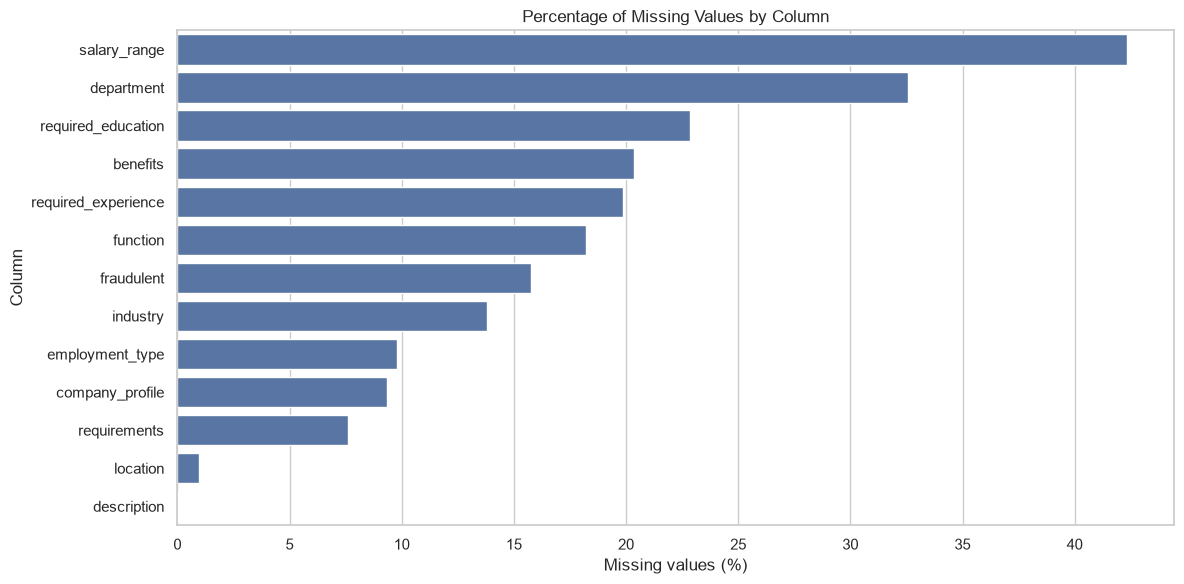

In [27]:
#Visualisation 1: Missing values before cleaning
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index)

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

### 14.2 Distribution of Genuine and Fraudulent Job Postings

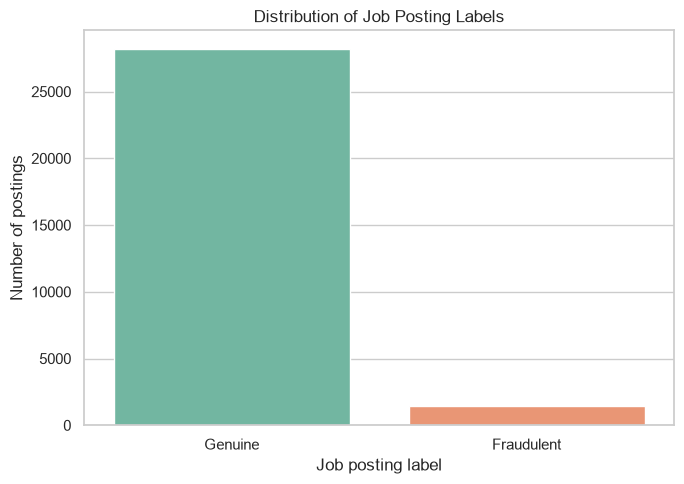

In [28]:
#Visualisation 2: Genuine vs fraudulent postings
plt.figure(figsize=(7, 5))

sns.countplot(
    data=labelled_df,
    x="fraudulent",
    hue="fraudulent",
    order=[0, 1],
    palette="Set2",
    legend=False
)

plt.xticks([0, 1], ["Genuine", "Fraudulent"])
plt.title("Distribution of Job Posting Labels")
plt.xlabel("Job posting label")
plt.ylabel("Number of postings")
plt.tight_layout()
plt.show()

### 14.3 Fraud Percentage by Employment Type

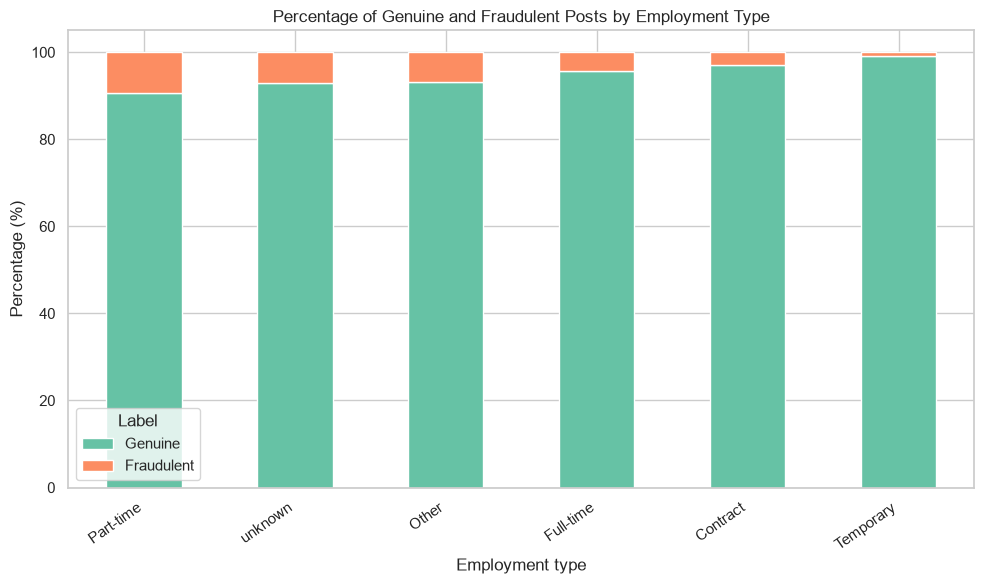

In [29]:
#Visualisation 3: Fraud percentage by employment type:
employment_fraud = pd.crosstab(
    labelled_df["employment_type"].fillna("Unknown"),
    labelled_df["fraudulent"],
    normalize="index"
) * 100

employment_fraud = employment_fraud.rename(
    columns={0: "Genuine", 1: "Fraudulent"}
)

employment_fraud = employment_fraud.sort_values(
    "Fraudulent", ascending=False
)

employment_fraud[["Genuine", "Fraudulent"]].plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["#66c2a5", "#fc8d62"]
)

plt.title("Percentage of Genuine and Fraudulent Posts by Employment Type")
plt.xlabel("Employment type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Label")
plt.tight_layout()
plt.show()

### 14.4 Company Logo Presence and Fraud Label

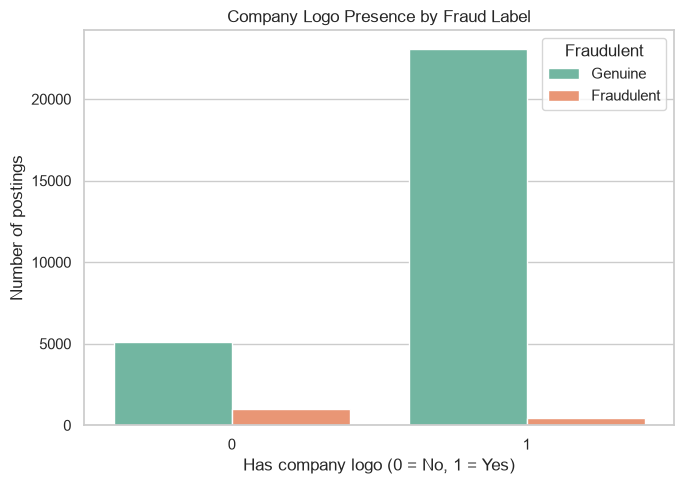

In [30]:
#Visualisation 4: Company logo vs fraud label:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=labelled_df,
    x="has_company_logo",
    hue="fraudulent",
    palette="Set2"
)

plt.title("Company Logo Presence by Fraud Label")
plt.xlabel("Has company logo (0 = No, 1 = Yes)")
plt.ylabel("Number of postings")
plt.legend(title="Fraudulent", labels=["Genuine", "Fraudulent"])
plt.tight_layout()
plt.show()

### 14.5 Job Description Length by Fraud Label

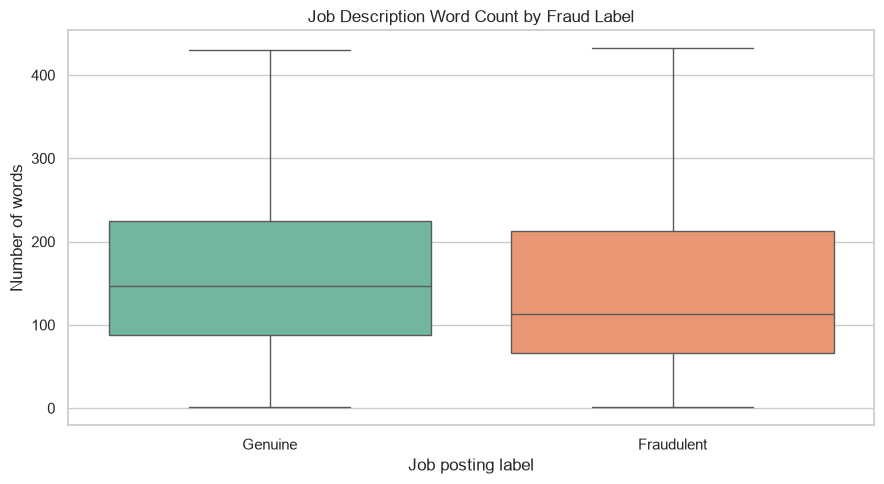

In [31]:
#Visualisation 5: Job description length:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=labelled_df,
    x="fraudulent",
    y="description_word_count",
    hue="fraudulent",
    palette="Set2",
    showfliers=False,
    legend=False
)

plt.xticks([0, 1], ["Genuine", "Fraudulent"])
plt.title("Job Description Word Count by Fraud Label")
plt.xlabel("Job posting label")
plt.ylabel("Number of words")
plt.tight_layout()
plt.show()

### 14.6 Fraudulent Proportion Across Major Industries

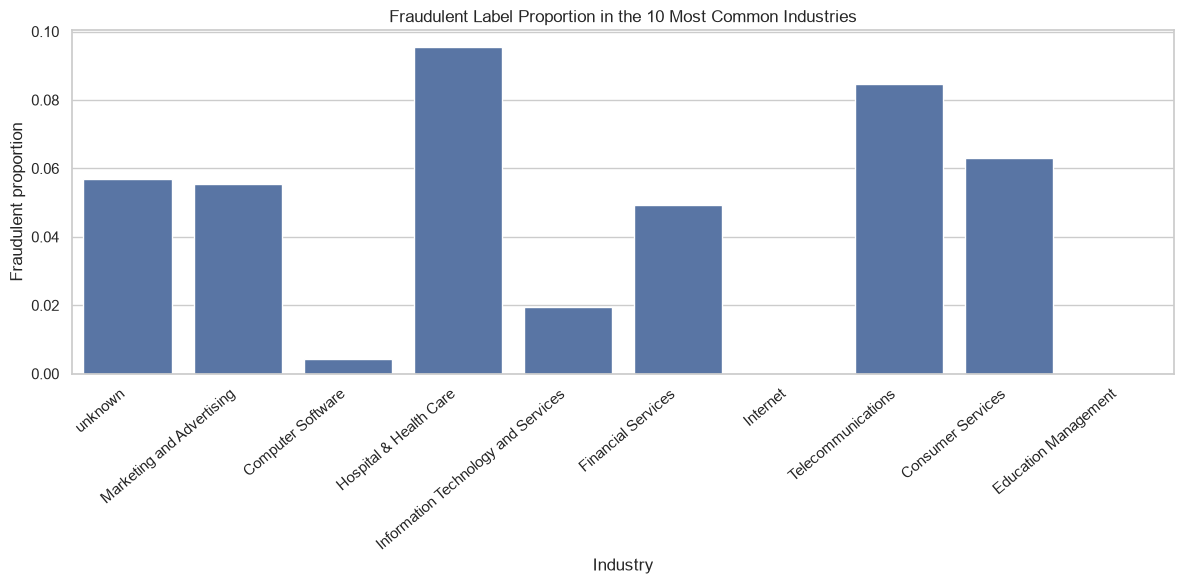

In [32]:
#Visualisation 6: Fraud proportions across job industries:
top_industries = (
    labelled_df["industry"]
    .fillna("Unknown")
    .value_counts()
    .head(10)
    .index
)

industry_df = labelled_df[
    labelled_df["industry"].fillna("Unknown").isin(top_industries)
].copy()

industry_df["industry"] = industry_df["industry"].fillna("Unknown")

plt.figure(figsize=(12, 6))

sns.barplot(
    data=industry_df,
    x="industry",
    y="fraudulent",
    estimator="mean",
    errorbar=None
)

plt.title("Fraudulent Label Proportion in the 10 Most Common Industries")
plt.xlabel("Industry")
plt.ylabel("Fraudulent proportion")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

### 14.7 Screening Questions and Fraud Label

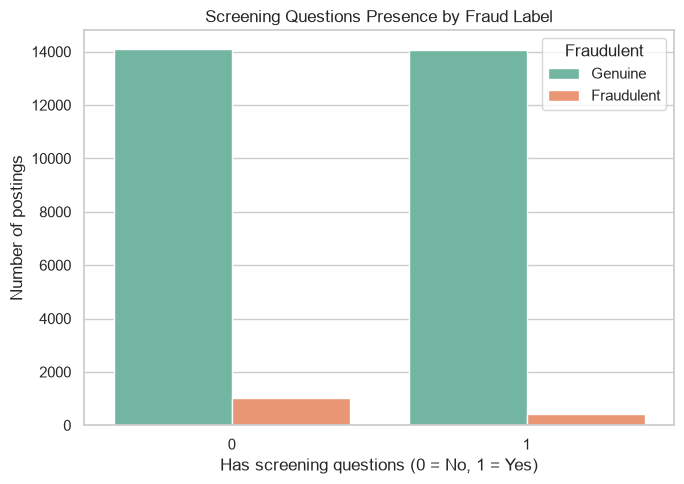

In [33]:
# Visualisation 7: Screening questions vs fraud label

plt.figure(figsize=(7, 5))

sns.countplot(
    data=labelled_df,
    x="has_questions",
    hue="fraudulent",
    palette="Set2"
)

plt.title("Screening Questions Presence by Fraud Label")
plt.xlabel("Has screening questions (0 = No, 1 = Yes)")
plt.ylabel("Number of postings")
plt.legend(title="Fraudulent", labels=["Genuine", "Fraudulent"])
plt.tight_layout()
plt.show()

### 14.8 Telecommuting Availability and Fraud Label

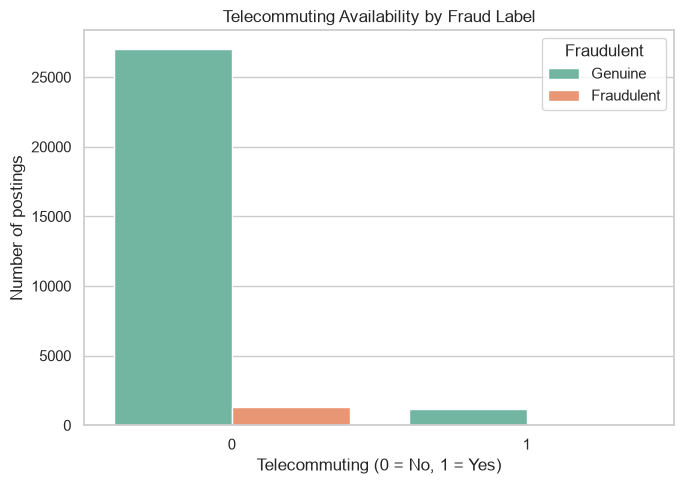

In [34]:
# Visualisation 8: Telecommuting vs fraud label

plt.figure(figsize=(7, 5))

sns.countplot(
    data=labelled_df,
    x="telecommuting",
    hue="fraudulent",
    palette="Set2"
)

plt.title("Telecommuting Availability by Fraud Label")
plt.xlabel("Telecommuting (0 = No, 1 = Yes)")
plt.ylabel("Number of postings")
plt.legend(title="Fraudulent", labels=["Genuine", "Fraudulent"])
plt.tight_layout()
plt.show()

### 15. Actual Findings and Key Insights

In [35]:
#6. Actual Findings:
# Overall fraud proportions
fraud_rate = labelled_df["fraudulent"].mean() * 100

print(f"Labelled postings: {len(labelled_df):,}")
print(f"Fraudulent postings: {(labelled_df['fraudulent'] == 1).sum():,}")
print(f"Genuine postings: {(labelled_df['fraudulent'] == 0).sum():,}")
print(f"Fraudulent proportion: {fraud_rate:.2f}%")

# Top industries by number of fraudulent postings
fraud_by_industry = (
    labelled_df[labelled_df["fraudulent"] == 1]
    ["industry"].fillna("Unknown")
    .value_counts()
    .head(10)
)

display(fraud_by_industry)

# Fraud proportions by company-logo presence
logo_summary = labelled_df.groupby("has_company_logo")[
    "fraudulent"
].agg(["count", "mean"])

logo_summary["fraud_percentage"] = logo_summary["mean"] * 100

display(logo_summary.round(2))

# Compare description word counts
display(
    labelled_df.groupby("fraudulent")["description_word_count"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

Labelled postings: 29,611
Fraudulent postings: 1,442
Genuine postings: 28,169
Fraudulent proportion: 4.87%


industry
unknown                                468
Oil & Energy                           178
Accounting                              94
Hospital & Health Care                  79
Marketing and Advertising               75
Financial Services                      63
Information Technology and Services     56
Telecommunications                      46
Consumer Services                       38
Leisure, Travel & Tourism               37
Name: count, dtype: int64

,count,mean,fraud_percentage
has_company_logo,,,
0,6092,0.16,16.05
1,23519,0.02,1.97


,count,mean,median,std
fraudulent,,,,
0,28169,170.99,147.0,122.82
1,1442,158.33,113.0,134.79


### 16. Key Findings

1. **Dataset quality:** The original dataset contained **35,479 rows and 18 columns**. Before cleaning, **35,599 missing values** were identified across the dataset, and **269 exact duplicate rows** were identified. Missing values were handled according to the meaning of each column, while the exact duplicate rows were removed where appropriate.

2. **Fraud-label distribution:** Among **29,611 postings with known labels**, **4.87%** were labelled fraudulent and **95.13%** were labelled genuine. This indicates that the labelled dataset is **highly imbalanced**, with genuine job postings representing the large majority of labelled records.

3. **Employment characteristics:** The employment-type analysis compared the fraudulent-label proportions across different employment categories. The category with the highest observed fraudulent proportion should be reported together with its labelled sample count after the corresponding analysis output is executed.

4. **Company information:** The analysis of company-logo presence compares fraud proportions between postings with and without company logos. The exact percentages should be taken from the `logo_summary` output generated in the notebook.

5. **Job description text:** The analysis compares the median job-description word count between genuine and fraudulent postings. The exact median values should be taken from the `description_word_count` analysis output after the cell is executed.

6. **Industry patterns:** The industry analysis examines fraudulent postings across the major industries and compares their fraudulent proportions. The industry with the highest number of fraudulent postings should be reported from the `fraud_by_industry` output.

7. **Statistical analysis:** A **Chi-Square test of independence** was included to examine the association between company-logo presence and fraud labels. The exact chi-square statistic and p-value need to be taken from the executed `chi2_contingency()` output before stating whether the association is statistically significant at the 0.05 level.

### 17. Conclusion

This exploratory data analysis examined job-posting characteristics associated with recorded recruitment-fraud labels. Data cleaning, descriptive statistics, cross-tabulation, and visualisation were used to understand the dataset, its missing information, label distribution, employment characteristics, company information, and job-description text.

The analysis identified [insert two or three key findings from your results]. These findings describe patterns and associations within the available dataset; they do not prove that any single characteristic causes a posting to be fraudulent. Missing or unknown labels were treated separately to avoid incorrectly classifying them as genuine.

The results can support further investigation into recruitment-fraud patterns and provide a foundation for future work on automated job-posting risk assessment.